# Insurance Claims - Data Processing and Modelling 

<div style="background-color:lightyellow; padding:10px;"

## Overview

1. Load packages
2. Preprocessing
3. Label encode target (fraud= 1/non-fraud=0)
4. Train/Test Split
    - Imbalance and metric
5. Modelling simple models (imbalanced dataset)
6. Resampling sets
    - RandomOverSampler
    - Smote Tomek
7. Lazy Predictor on resampled sets



17. KFold - ensure stable scores, robustness of models


## 1. Load packages

In [145]:
import pandas as pd
import numpy as np
from sklearn import model_selection, preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from lazypredict.Supervised import LazyClassifier
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier


## 2. Preprocessing 

In [146]:
#import
df=pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")
#check duplicates
print('Duplicated: ', df.duplicated().sum() )
print('\n')
#ensure consistency on column names 
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)
#Rename Strings from '?' to 'Unkown'
df["collision_type"]=df["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
df["police_report_available"]=df["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
df["property_damage"]=df["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)
# drop column as 100% nan-values
# drop umbrella limits as 80% of values are zeros, std = 1.1 Mio
df.drop(['months_as_customer',  'umbrella_limit',  'total_claim_amount', '_c39'],axis=1,inplace= True)

# drop columns where p_value <5% or highly correlated with other variables
df.drop('age',axis=1,inplace=True)
df.drop('policy_bind_date',axis=1,inplace=True)
df.drop('policy_state',axis=1,inplace=True)
df.drop('policy_csl',axis=1,inplace=True)
df.drop('policy_deductable',axis=1,inplace=True)
df.drop('policy_annual_premium',axis=1,inplace=True)
df.drop('insured_zip',axis=1,inplace=True)
df.drop('insured_sex',axis=1,inplace=True)
df.drop('insured_education_level',axis=1,inplace=True)
df.drop('insured_occupation',axis=1,inplace=True)
df.drop('insured_relationship',axis=1,inplace=True)
df.drop('capital_gains',axis=1,inplace=True)
df.drop('capital_loss',axis=1,inplace=True)
df.drop('incident_date',axis=1,inplace=True)
df.drop('incident_city',axis=1,inplace=True)
df.drop('incident_location',axis=1,inplace=True)
df.drop('incident_hour_of_the_day',axis=1,inplace=True)
df.drop('number_of_vehicles_involved',axis=1,inplace=True)
df.drop('property_damage',axis=1,inplace=True)
df.drop('bodily_injuries',axis=1,inplace=True)
df.drop('witnesses',axis=1,inplace=True)
df.drop('police_report_available',axis=1,inplace=True)
df.drop('injury_claim',axis=1,inplace=True) # high correlation with total_claim_amount
df.drop('property_claim',axis=1,inplace=True) # high correlation with total_claim_amount
# df.drop('vehicle_claim',axis=1,inplace=True)
df.drop('auto_make',axis=1,inplace=True)
df.drop('auto_model',axis=1,inplace=True)
df.drop('auto_year',axis=1,inplace=True)
#check columns
print('Remaining features: ', df.columns)
print('\n')
print('Missing values: ', df.isna().sum().sum() , 'in the variable authorities_contacted, ' \
'they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.')
print('\n')
print(df.info())
df.head()


Duplicated:  0


Remaining features:  Index(['insured_hobbies', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'vehicle_claim', 'fraud_reported'],
      dtype='object')


Missing values:  91 in the variable authorities_contacted, they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 521585 to 556080
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   insured_hobbies        1000 non-null   object
 1   incident_type          1000 non-null   object
 2   collision_type         1000 non-null   object
 3   incident_severity      1000 non-null   object
 4   authorities_contacted  909 non-null    object
 5   incident_state         1000 non-null   object
 6   vehicle_claim          1000 non-null   int64 
 7   fraud_reported         1000

,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,vehicle_claim,fraud_reported
policy_number,,,,,,,,
521585,sleeping,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,52080,Y
342868,reading,Vehicle Theft,No Collision,Minor Damage,Police,VA,3510,Y
687698,board-games,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,23100,N
227811,board-games,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,50720,Y
367455,board-games,Vehicle Theft,No Collision,Minor Damage,NaN,NY,4550,N


## 3. Label encode target (fraud= 1/non-fraud=0)

In [147]:
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])
#labels: 0 = No Fraud, 1 = Fraud

## 4.  Train Test Split  and X,y Split

In [148]:
#X / y split
X=df.drop('fraud_reported', axis=1)
y=df['fraud_reported']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train Set: ' , X_train.shape)
print('Test Set: ' , X_test.shape)

#missing values treatment with SIMPLE IMPUTER
#define numerical and categorical columns
categorical_columns=['authorities_contacted']
# instantiate imputers
categorical_imputer=SimpleImputer(strategy='most_frequent')
#apply to categorical columns
X_train[categorical_columns]=categorical_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns]=categorical_imputer.transform(X_test[categorical_columns])


# Nominal-categorical variables; one-hot encoding is preferred in this case

# Resetting the index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #sparse_output=False
# Select only the nominal var columns for encoding
columns_to_encode = ['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']
# Fit the encoder on the training set and transform both the training and test sets
encoder.fit(X_train[columns_to_encode])
# Encode the nominal vars columns for both datasets
X_train_encoded = encoder.transform(X_train[columns_to_encode])
X_test_encoded = encoder.transform(X_test[columns_to_encode])

# Convert the encoded arrays to DataFrames
train_encoded_df = pd.DataFrame(X_train_encoded, index=X_train.index, columns=encoder.get_feature_names_out(columns_to_encode)) #index=X_train.index
test_encoded_df = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoder.get_feature_names_out(columns_to_encode)) #index=X_test.index

# Drop the original nominal vars column and concatenate the new encoded columns
X_train = pd.concat([X_train.drop(columns=columns_to_encode), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=columns_to_encode), test_encoded_df], axis=1)


print('Train Set after OHE: ' , X_train.shape)
print('Test Set after OHE: ' , X_test.shape)


#Scaling (normalization) of numerical variables
minmax_scaler = MinMaxScaler()
minmax_col = ['vehicle_claim']
for column in minmax_col:
    X_train[column] = minmax_scaler.fit_transform(X_train[[column]])
    X_test[column] = minmax_scaler.transform(X_test[[column]])

X_train.head()

Train Set:  (800, 7)
Test Set:  (200, 7)
Train Set after OHE:  (800, 44)
Test Set after OHE:  (200, 44)


,vehicle_claim,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,insured_hobbies_dancing,insured_hobbies_exercise,...,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
0,0.80,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,0.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
2,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


<div style="background-color:lightyellow; padding:10px;"

### Imbalance & Metric
- Due to the imbalanced nature of our dataset we will resample our dataset, trying different techniques.

**Metric**
- Focus will be on the F1 Score and Recall. 
- Greater focus on the F1 score for our target = 1 (fraud positive) 



In [191]:
# value counts y
y_train.value_counts(normalize=True)


fraud_reported
0   0.76
1   0.24
Name: proportion, dtype: float64

## 5. Modelling - Simple models with the imbalanced sets

<div style="background-color:lightyellow; padding:10px;"

### - Best models before resampling: 
- LDA and Ridge
    - small overfitting
    - best F1 scores

### Before resampling shows practically NO OVERFITTING!!! Why? In this sense much better than after resampling..... should we keep imbalanced sets instead of resampling?

</div>


F1 Scores for the Positive Class:


,Model,Test F1,Train F1
0,Logistic Regression,0.69,0.73
1,Decision Tree,0.60,1.00
2,Random Forest,0.72,1.00
3,Ridge Classifier,0.75,0.75
4,SVC,0.69,0.81
5,Linear Discriminant Analysis,0.74,0.76
6,AdaBoost,0.59,0.64
7,XGBoost,0.60,0.99



F1 Scores (Weighted Average):


,Model,Test F1 (weighted),Train F1 (weighted)
0,Logistic Regression,0.82,0.87
1,Decision Tree,0.78,1.00
2,Random Forest,0.84,1.00
3,Ridge Classifier,0.85,0.87
4,SVC,0.82,0.91
5,Linear Discriminant Analysis,0.84,0.88
6,AdaBoost,0.79,0.84
7,XGBoost,0.79,1.00


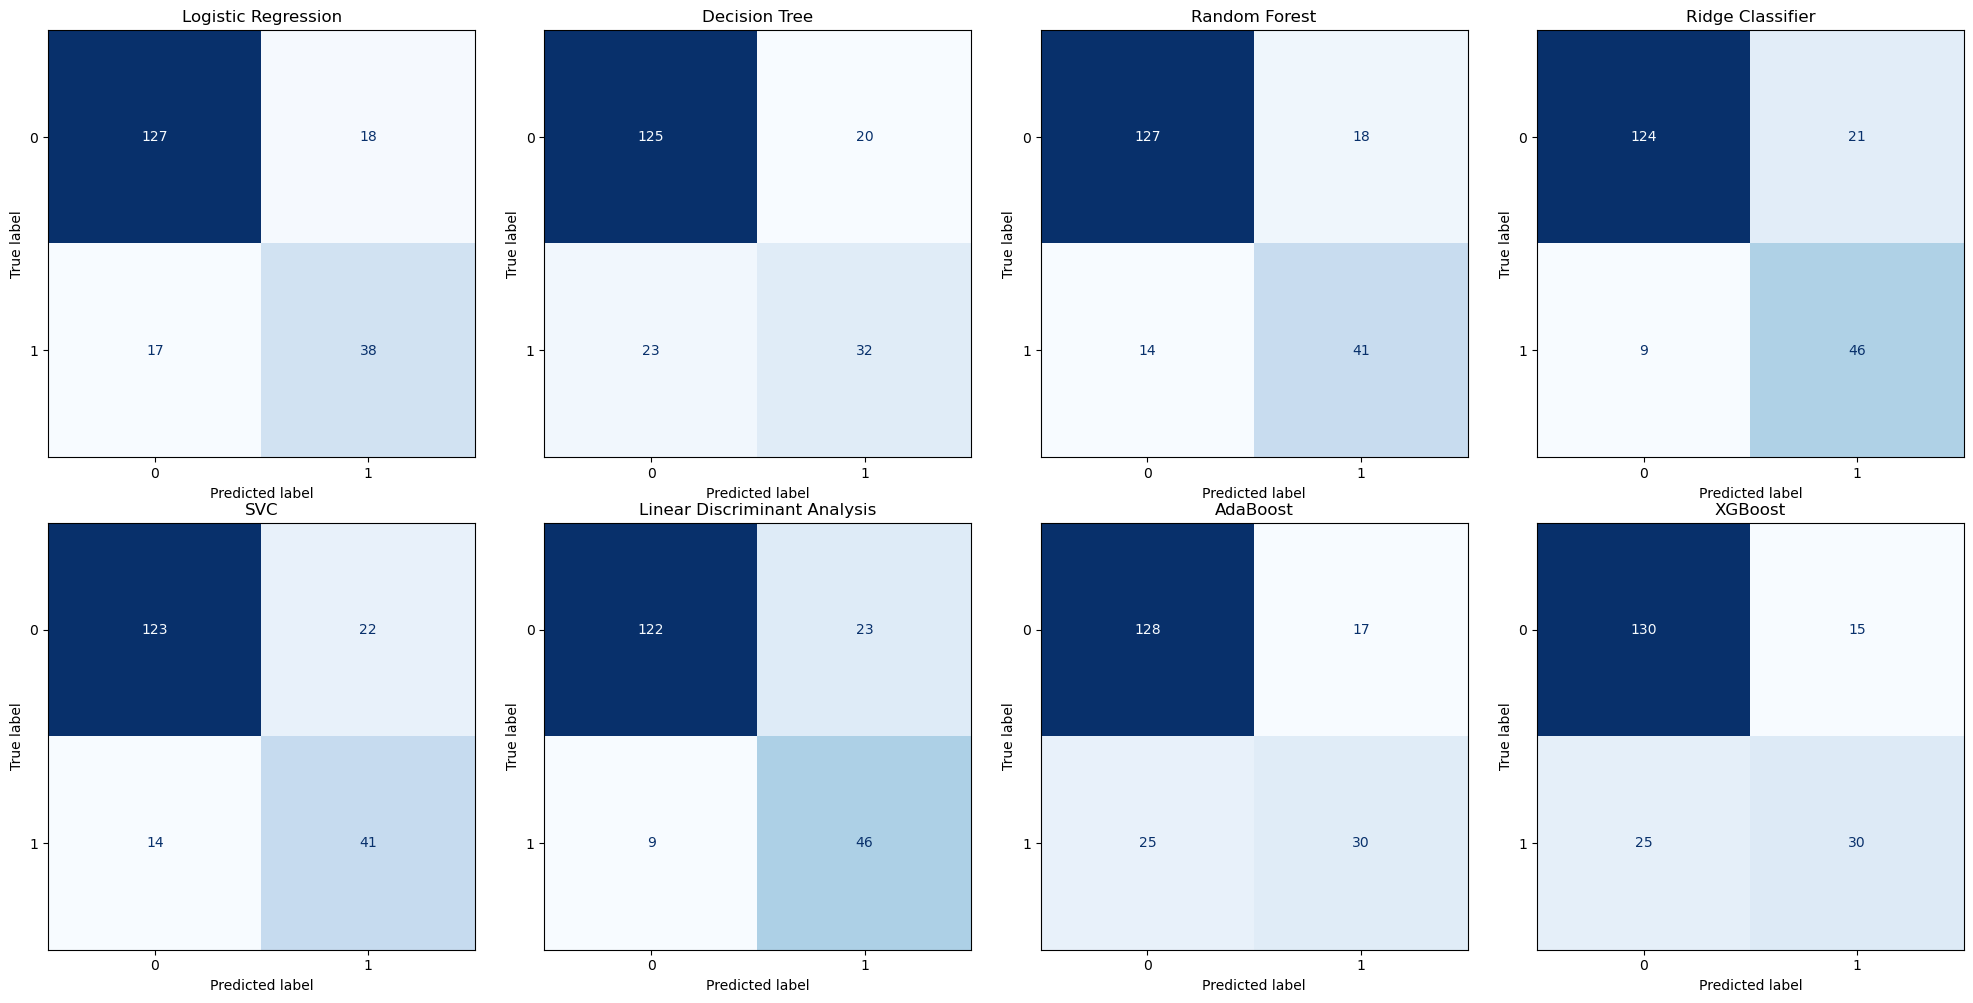

       Classification Report for Logistic Regression        
              precision  recall  f1-score  support
0                  0.88    0.88      0.88   145.00
1                  0.68    0.69      0.68    55.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.78    0.78      0.78   200.00
weighted avg       0.83    0.82      0.83   200.00


          Classification Report for Decision Tree           
              precision  recall  f1-score  support
0                  0.84    0.86      0.85   145.00
1                  0.62    0.58      0.60    55.00
accuracy           0.79    0.79      0.79     0.79
macro avg          0.73    0.72      0.73   200.00
weighted avg       0.78    0.79      0.78   200.00


          Classification Report for Random Forest           
              precision  recall  f1-score  support
0                  0.90    0.88      0.89   145.00
1                  0.69    0.75      0.72    55.00
accuracy           0.84    0.84      0.84     0.

In [155]:
# Models and their full names
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# F1 Scores (Positive Class)
print("F1 Scores for the Positive Class:")
results_f1 = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    test_f1 = f1_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train, y_pred_train)
    results_f1.append({'Model': model_name, 'Test F1': test_f1, 'Train F1': train_f1})
df_f1 = pd.DataFrame(results_f1)
display(round(df_f1, 3))

# F1 Scores (Weighted Average)
print("\nF1 Scores (Weighted Average):")
results_f1_weighted = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')
    train_f1 = f1_score(y_train, y_pred_train, average='weighted')
    results_f1_weighted.append({'Model': model_name, 'Test F1 (weighted)': test_f1, 'Train F1 (weighted)': train_f1})
df_f1_weighted = pd.DataFrame(results_f1_weighted)
display(round(df_f1_weighted, 3))

# Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) #Adjusted subplots for 8 models
axes = axes.flatten()
model_list = list(models.keys())
for i, model_name in enumerate(model_list):
    model = models[model_name]
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(model_name)
    axes[i].grid(False)
for j in range(len(model_list), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Classification Reports
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    report = classification_report(y_test, y_pred_test, output_dict=True)
    print("=" * 60)
    print(f"{'Classification Report for ' + model_name:^60}")
    print("=" * 60)
    df_report = pd.DataFrame(report).transpose()
    print(df_report)
    print("\n")

## 6. Resampling with RO, SmoteTomek


<div style="background-color:lightyellow; padding:10px;"


- both techniques give similar/same good results. We will proceed the gridsearch with SmoteTomek
- Smote can generate noisy samples by creating new points between marginal outliers and outliers. This problem can be solved by cleaning the resulting oversampling space. (SmoteTomek, oversampling from Smote, undersampling using Tomek)



### - Best models after resampling: 
- LDA and Ridge
    - small overfitting
    - best F1 scores
Gridsearch performed further below in point 9. We used SmoteTomek set. The best params for the best scores have been added to the models. 


In [161]:
#instantiate resampling methods
ros=RandomOverSampler(random_state=42)
rus=RandomUnderSampler(random_state=42)
smotetom = SMOTETomek(random_state=42)

# resample X_train, y_train using ros, smote, rus and st
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
X_train_smotetom, y_train_smotetom = smotetom.fit_resample(X_train, y_train)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
# check the number of samples in each class
print("Original dataset shape:", y_train.value_counts())
print("RandomOverSampler dataset shape:", y_train_ros.value_counts())
print("SMOTETomek dataset shape:", y_train_smotetom.value_counts())
print("RandomUnderSampler dataset shape:", y_train_rus.value_counts())


Original dataset shape: fraud_reported
0    608
1    192
Name: count, dtype: int64
RandomOverSampler dataset shape: fraud_reported
0    608
1    608
Name: count, dtype: int64
SMOTETomek dataset shape: fraud_reported
0    598
1    598
Name: count, dtype: int64
RandomUnderSampler dataset shape: fraud_reported
0    192
1    192
Name: count, dtype: int64


### RandomOverSampler


<div style="background-color:yellow; padding:10px;"> #### ALL OVERFITTING WITH ROS </div>

F1 Scores for the Positive Class:


,Model,Test F1,Train F1
0,Logistic Regression,0.76,0.87
1,Decision Tree,0.59,1.00
2,Random Forest,0.69,1.00
3,Ridge Classifier,0.74,0.87
4,SVC,0.75,0.90
5,Linear Discriminant Analysis,0.74,0.87
6,AdaBoost,0.74,0.87
7,XGBoost,0.66,1.00



F1 Scores (Weighted Average):


,Model,Test F1 (weighted),Train F1 (weighted)
0,Logistic Regression,0.85,0.87
1,Decision Tree,0.78,1.00
2,Random Forest,0.82,1.00
3,Ridge Classifier,0.84,0.87
4,SVC,0.85,0.89
5,Linear Discriminant Analysis,0.84,0.87
6,AdaBoost,0.84,0.87
7,XGBoost,0.81,1.00


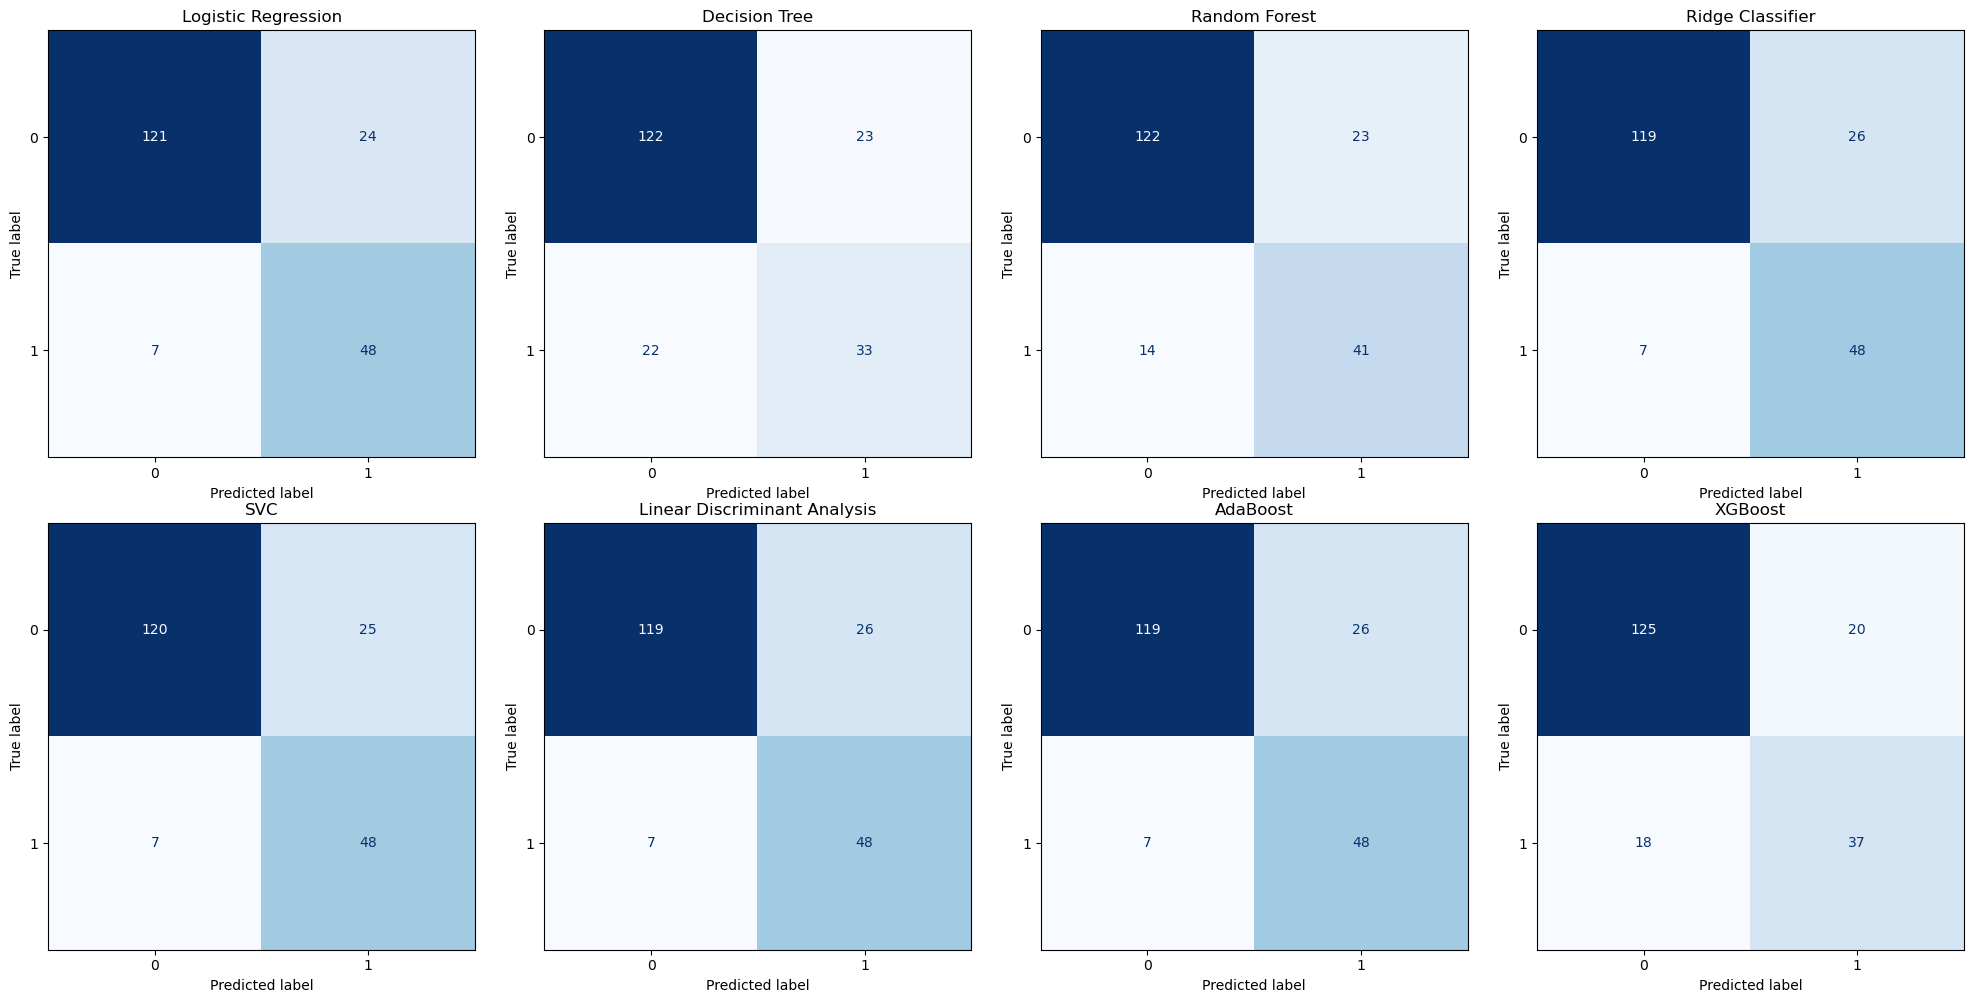

       Classification Report for Logistic Regression        
              precision  recall  f1-score  support
0                  0.95    0.83      0.89   145.00
1                  0.67    0.87      0.76    55.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.81    0.85      0.82   200.00
weighted avg       0.87    0.84      0.85   200.00


          Classification Report for Decision Tree           
              precision  recall  f1-score  support
0                  0.85    0.84      0.84   145.00
1                  0.59    0.60      0.59    55.00
accuracy           0.78    0.78      0.78     0.78
macro avg          0.72    0.72      0.72   200.00
weighted avg       0.78    0.78      0.78   200.00


          Classification Report for Random Forest           
              precision  recall  f1-score  support
0                  0.90    0.84      0.87   145.00
1                  0.64    0.75      0.69    55.00
accuracy           0.81    0.81      0.81     0.

In [162]:
# Models and their full names
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'SVC': SVC(random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

# F1 Scores (Positive Class)
print("F1 Scores for the Positive Class:")
results_f1 = []
for model_name, model in models.items():
    model.fit(X_train_ros, y_train_ros)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train_ros)
    test_f1 = f1_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train_ros, y_pred_train)
    results_f1.append({'Model': model_name, 'Test F1': test_f1, 'Train F1': train_f1})
df_f1 = pd.DataFrame(results_f1)
display(round(df_f1, 3))

# F1 Scores (Weighted Average)
print("\nF1 Scores (Weighted Average):")
results_f1_weighted = []
for model_name, model in models.items():
    model.fit(X_train_ros, y_train_ros)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train_ros)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')
    train_f1 = f1_score(y_train_ros, y_pred_train, average='weighted')
    results_f1_weighted.append({'Model': model_name, 'Test F1 (weighted)': test_f1, 'Train F1 (weighted)': train_f1})
df_f1_weighted = pd.DataFrame(results_f1_weighted)
display(round(df_f1_weighted, 3))

# Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) #Adjusted subplots for 8 models
axes = axes.flatten()
model_list = list(models.keys())
for i, model_name in enumerate(model_list):
    model = models[model_name]
    model.fit(X_train_ros, y_train_ros)
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(model_name)
    axes[i].grid(False)
for j in range(len(model_list), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Classification Reports
for model_name, model in models.items():
    model.fit(X_train_ros, y_train_ros)
    y_pred_test = model.predict(X_test)
    report = classification_report(y_test, y_pred_test, output_dict=True)
    print("=" * 60)
    print(f"{'Classification Report for ' + model_name:^60}")
    print("=" * 60)
    df_report = pd.DataFrame(report).transpose()
    print(df_report)
    print("\n")

### Smotetomek

F1 Scores for the Positive Class:


,Model,Test F1,Train F1
0,Logistic Regression,0.75,0.89
1,Decision Tree,0.65,1.00
2,Random Forest,0.73,1.00
3,Ridge Classifier,0.75,0.89
4,SVC,0.74,0.93
5,Linear Discriminant Analysis,0.75,0.89
6,AdaBoost,0.74,0.91
7,XGBoost,0.68,1.00



F1 Scores (Weighted Average):


,Model,Test F1 (weighted),Train F1 (weighted)
0,Logistic Regression,0.84,0.89
1,Decision Tree,0.82,1.00
2,Random Forest,0.85,1.00
3,Ridge Classifier,0.85,0.89
4,SVC,0.84,0.93
5,Linear Discriminant Analysis,0.85,0.89
6,AdaBoost,0.84,0.90
7,XGBoost,0.82,1.00


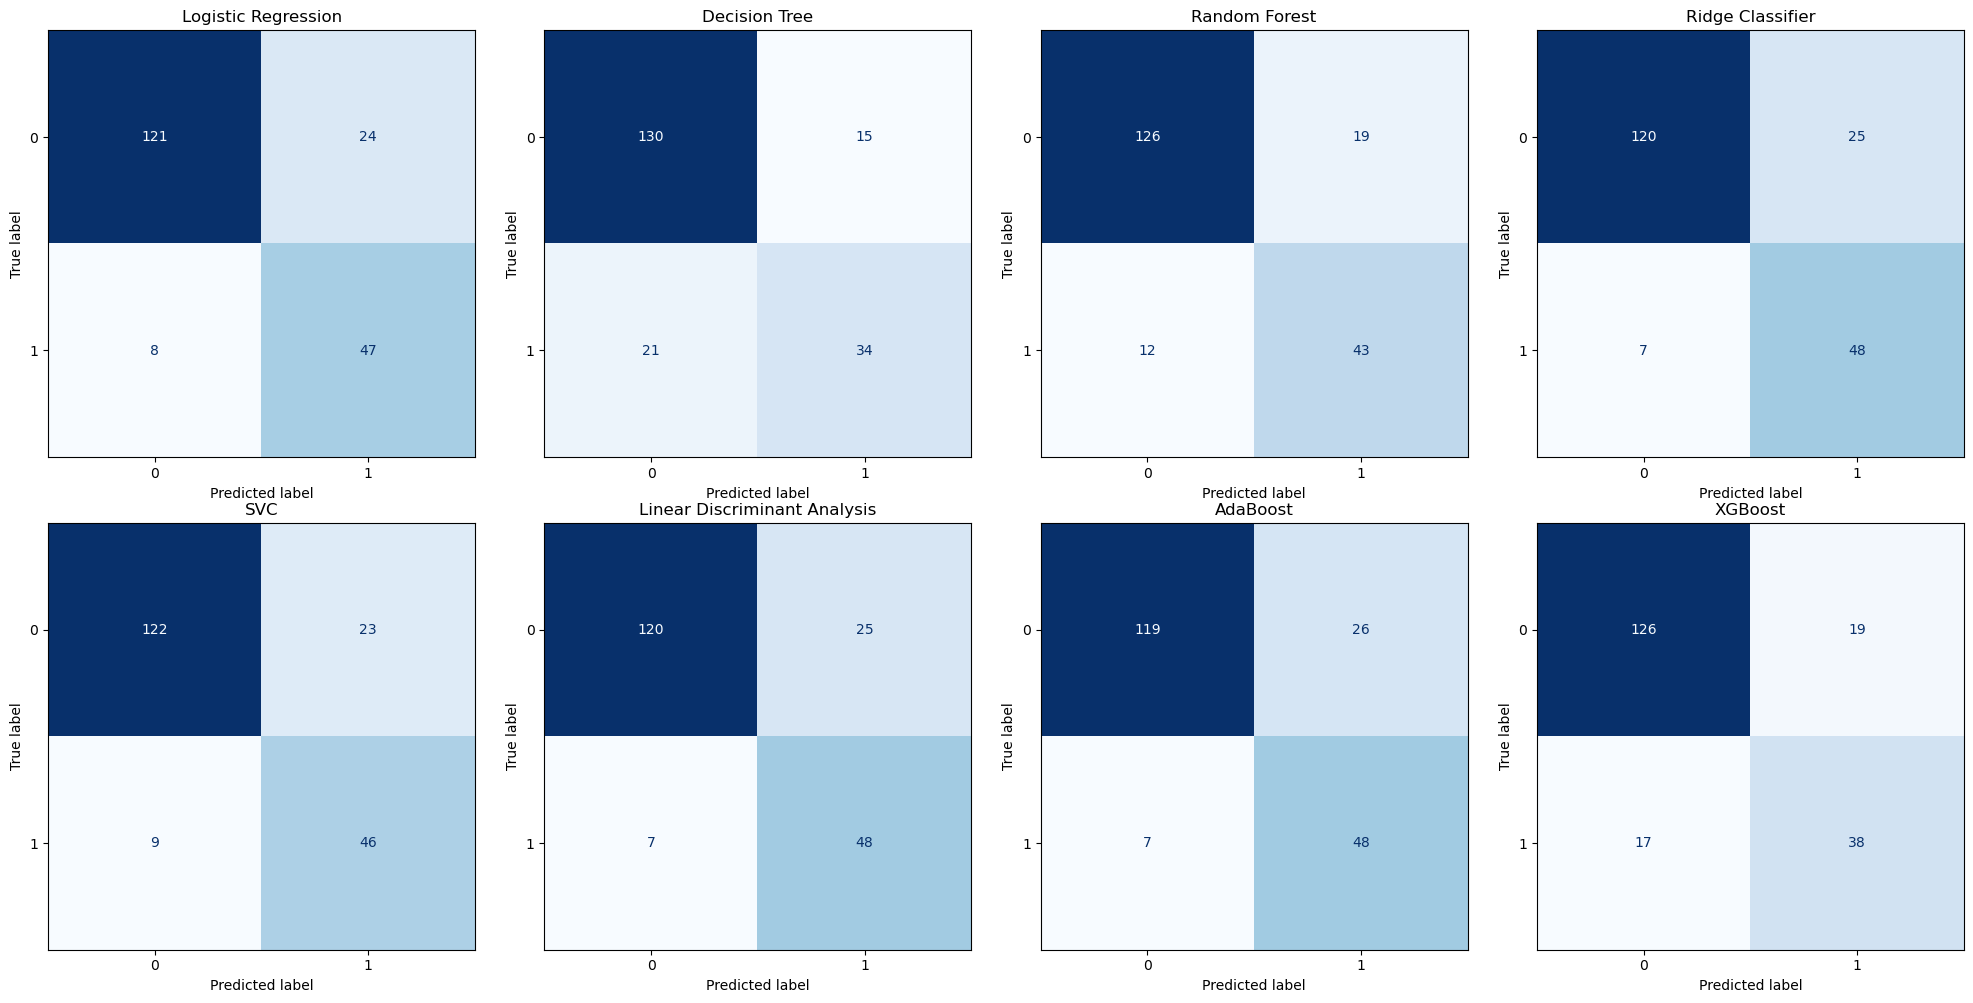

       Classification Report for Logistic Regression        
              precision  recall  f1-score  support
0                  0.94    0.83      0.88   145.00
1                  0.66    0.85      0.75    55.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.80    0.84      0.81   200.00
weighted avg       0.86    0.84      0.85   200.00


          Classification Report for Decision Tree           
              precision  recall  f1-score  support
0                  0.86    0.90      0.88   145.00
1                  0.69    0.62      0.65    55.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.78    0.76      0.77   200.00
weighted avg       0.81    0.82      0.82   200.00


          Classification Report for Random Forest           
              precision  recall  f1-score  support
0                  0.91    0.87      0.89   145.00
1                  0.69    0.78      0.74    55.00
accuracy           0.84    0.84      0.84     0.

In [ ]:
# Models and their full names
models = {
    'Logistic Regression': LogisticRegression(random_state=42),  
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42, solver='auto', alpha=0.01),  # Added valid parameters
    'SVC': SVC(random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(solver='svd', shrinkage=None),  # Added valid parameters
    'AdaBoost': AdaBoostClassifier(random_state=42, algorithm='SAMME', learning_rate=0.1, n_estimators=300),  # Added valid parameters
    'XGBoost': XGBClassifier(random_state=42)
}


"""
Grid Search for Linear Discriminant Analysis
Best Parameters: {'shrinkage': None, 'solver': 'svd'}
Best F1 Score: 0.8900

Grid Search for Ridge Classifier
Best Parameters: {'alpha': 0.01, 'solver': 'auto'}
Best F1 Score: 0.8900

Gridsearch for AdaBoost
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 300}
Best F1 Score: 0.9027

"""
# F1 Scores (Positive Class)
print("F1 Scores for the Positive Class:")
results_f1 = []
for model_name, model in models.items():
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train_smotetom)
    test_f1 = f1_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train_smotetom, y_pred_train)
    results_f1.append({'Model': model_name, 'Test F1': test_f1, 'Train F1': train_f1})
df_f1 = pd.DataFrame(results_f1)
display(round(df_f1, 3))

# F1 Scores (Weighted Average)
print("\nF1 Scores (Weighted Average):")
results_f1_weighted = []
for model_name, model in models.items():
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train_smotetom)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')
    train_f1 = f1_score(y_train_smotetom, y_pred_train, average='weighted')
    results_f1_weighted.append({'Model': model_name, 'Test F1 (weighted)': test_f1, 'Train F1 (weighted)': train_f1})
df_f1_weighted = pd.DataFrame(results_f1_weighted)
display(round(df_f1_weighted, 3))

# Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10)) #Adjusted subplots for 8 models
axes = axes.flatten()
model_list = list(models.keys())
for i, model_name in enumerate(model_list):
    model = models[model_name]
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(model_name)
    axes[i].grid(False)
for j in range(len(model_list), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Classification Reports
for model_name, model in models.items():
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    report = classification_report(y_test, y_pred_test, output_dict=True)
    print("=" * 60)
    print(f"{'Classification Report for ' + model_name:^60}")
    print("=" * 60)
    df_report = pd.DataFrame(report).transpose()
    print(df_report)
    print("\n")

## 7. Lazy predictor resampled sets

- Calibrated Classifier tested in notebook 2, as it is top in lazy classifier, however it had strong overfitting. 

In [175]:
# object
clf = LazyClassifier(random_state=42)
# fit
models = clf.fit(X_train_smotetom, X_test, y_train_smotetom, y_test)
# print
print('\n')
print('Smote Tomek')

#sort by F1 score
models[1].sort_values(by='F1 Score', ascending=False, inplace=True)
# print
models[1].head(10)

100%|██████████| 32/32 [00:03<00:00,  8.24it/s]

[LightGBM] [Info] Number of positive: 598, number of negative: 598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 875
[LightGBM] [Info] Number of data points in the train set: 1196, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Smote Tomek


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
CalibratedClassifierCV,0.84,0.85,0.85,0.85,0.17
LinearSVC,0.84,0.85,0.85,0.85,0.05
RandomForestClassifier,0.84,0.83,0.83,0.85,0.39
LinearDiscriminantAnalysis,0.84,0.85,0.85,0.85,0.07
RidgeClassifierCV,0.84,0.85,0.85,0.85,0.06
RidgeClassifier,0.84,0.85,0.85,0.85,0.05
AdaBoostClassifier,0.84,0.84,0.84,0.84,0.71
LogisticRegression,0.84,0.84,0.84,0.84,0.06
NuSVC,0.83,0.82,0.82,0.84,0.27


## 8. Features importance on LDA as it is best model

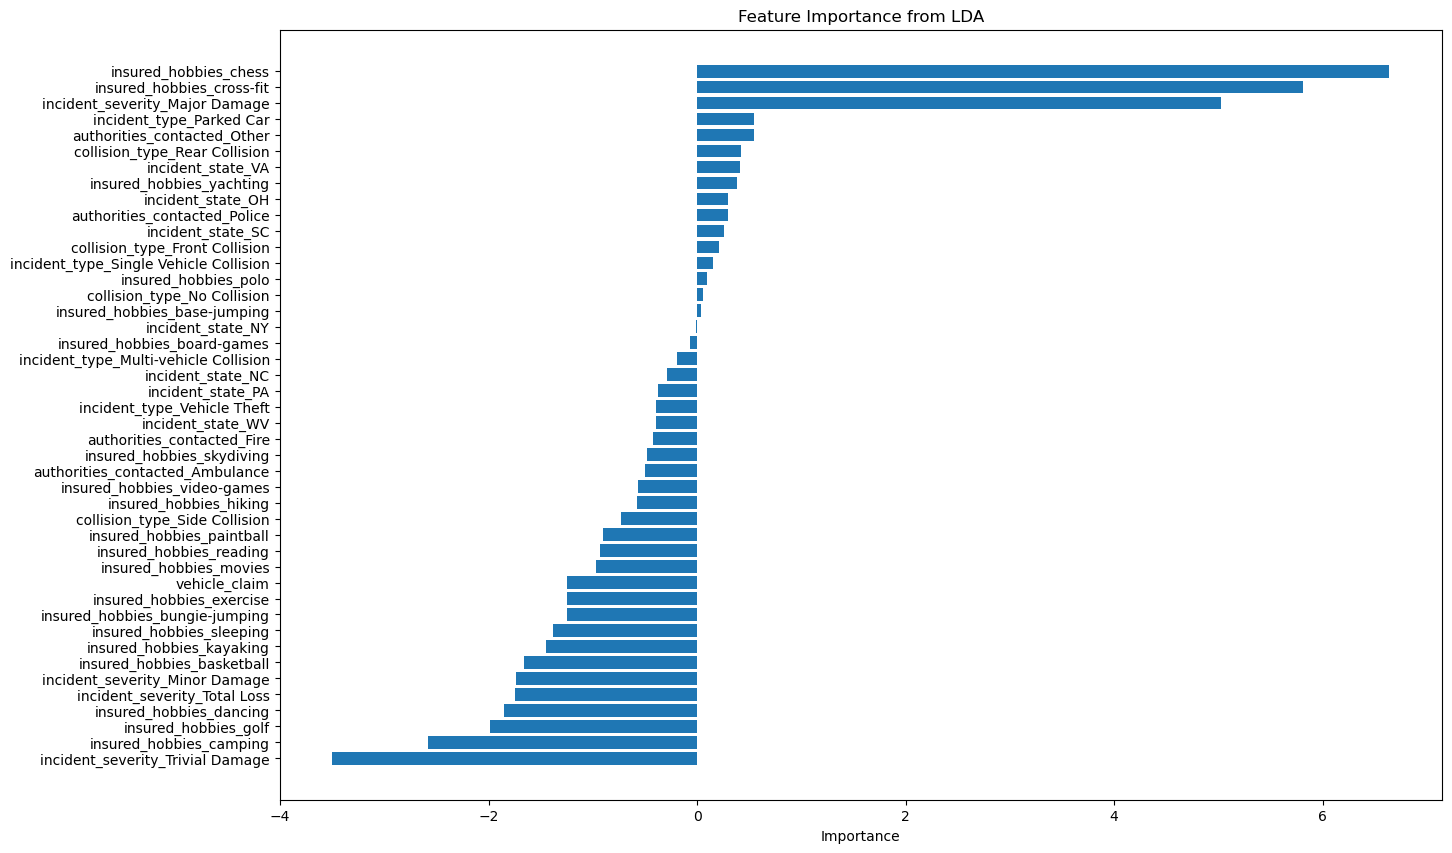

In [170]:
# lda features importance
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_smotetom, y_train_smotetom)
importance = lda.coef_[0]
# summarize feature importance
feature_names = X_train_smotetom.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# plot feature importance
plt.figure(figsize=(15, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from LDA')
plt.gca().invert_yaxis()
plt.show()

## 9. Gridsearches / Hyperparameter Optimization Smote Tomek
(RandomizedSearch for SVC, otherwise takes forever)

- best parameters already added to LDA and Ridge

#### Gridsearch for LDA, Ridge, AdaBoost

Grid Search for Linear Discriminant Analysis


Best Parameters: {'shrinkage': None, 'solver': 'svd'}
Best F1 Score: 0.8900

Grid Search for Ridge Classifier
Best Parameters: {'alpha': 0.01, 'solver': 'auto'}
Best F1 Score: 0.8900

Grid Search for AdaBoostClassifier


/opt/anaconda3/envs/Env1/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/envs/Env1/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/envs/Env1/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/envs/Env1/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/opt/anaconda3/envs/Env1/lib/python3.11/site-packages/sklearn/ensemble/_weight_boost

Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 300}
Best F1 Score: 0.9027

Linear Discriminant Analysis - Test F1: 0.7500, Train F1: 0.8927
Ridge Classifier - Test F1: 0.7500, Train F1: 0.8927
AdaBoostClassifier - Test F1: 0.7442, Train F1: 0.9092


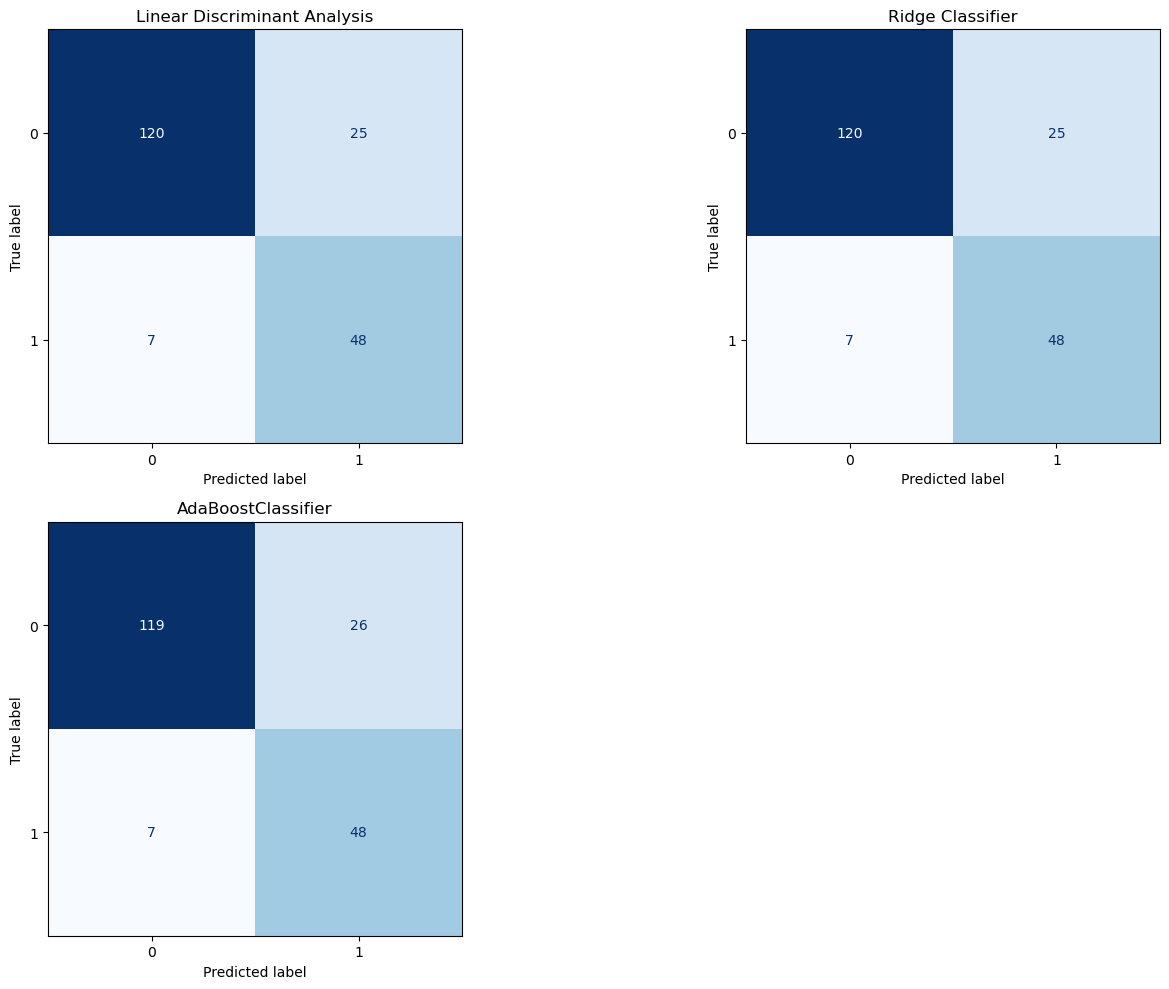

   Classification Report for Linear Discriminant Analysis   
              precision  recall  f1-score  support
0                  0.94    0.83      0.88   145.00
1                  0.66    0.87      0.75    55.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.80    0.85      0.82   200.00
weighted avg       0.87    0.84      0.85   200.00


         Classification Report for Ridge Classifier         
              precision  recall  f1-score  support
0                  0.94    0.83      0.88   145.00
1                  0.66    0.87      0.75    55.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.80    0.85      0.82   200.00
weighted avg       0.87    0.84      0.85   200.00


        Classification Report for AdaBoostClassifier        
              precision  recall  f1-score  support
0                  0.94    0.82      0.88   145.00
1                  0.65    0.87      0.74    55.00
accuracy           0.83    0.83      0.83     0.

In [ ]:
#grid search for lda, ridge, adaboost
# Define the parameter grid for each model
param_grid = {
        'Linear Discriminant Analysis': {
        'solver': ['svd', 'lsqr', 'eigen'], # Added 'eigen'
        'shrinkage': [None, 'auto', 0.1, 0.5, 0.9] # Added more shrinkage values
    },
    'Ridge Classifier': {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0], # Added more alpha values
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'] #Added more solvers
    },
    'AdaBoostClassifier': {
        'n_estimators': [25, 50, 100, 200, 300], # Added more n_estimators
        'learning_rate': [0.001, 0.01, 0.1, 1.0, 10.0], # Added more learning_rate values
        'algorithm': ['SAMME', 'SAMME.R'] # Added algorithm
}
}
# Initialize the models
models = {
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Ridge Classifier': RidgeClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
}
# Initialize a dictionary to store the best models
best_models = {}
# Perform Grid Search for each model
for model_name, model in models.items():
    print(f"Grid Search for {model_name}")
    grid_search = GridSearchCV(model, param_grid[model_name], cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train_smotetom, y_train_smotetom)
    best_models[model_name] = grid_search.best_estimator_
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best F1 Score: {grid_search.best_score_:.4f}\n")
# Evaluate the best models on the test set
for model_name, model in best_models.items():
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train_smotetom)
    test_f1 = f1_score(y_test, y_pred_test)
    train_f1 = f1_score(y_train_smotetom, y_pred_train)
    print(f"{model_name} - Test F1: {test_f1:.4f}, Train F1: {train_f1:.4f}")
# Confusion Matrices for the best models
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) #Adjusted subplots for 4 models
axes = axes.flatten()
model_list = list(best_models.keys())
for i, model_name in enumerate(model_list):
    model = best_models[model_name]
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(model_name)
    axes[i].grid(False)
for j in range(len(model_list), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()
# Classification Reports for the best models
for model_name, model in best_models.items():
    model.fit(X_train_smotetom, y_train_smotetom)
    y_pred_test = model.predict(X_test)
    report = classification_report(y_test, y_pred_test, output_dict=True)
    print("=" * 60)
    print(f"{'Classification Report for ' + model_name:^60}")
    print("=" * 60)
    df_report = pd.DataFrame(report).transpose()
    print(df_report)
    print("\n")
# Final Model Evaluation
# Choose the best model based on the F1 score


#### Randomizedsearch SVC

Best Parameters for SVC: {'C': np.float64(7.812703466859457), 'degree': 2, 'gamma': np.float64(0.0936300878513349), 'kernel': 'rbf'}
Best F1 Score for SVC: 0.9195934174408988
SVC - Test F1: 0.6949, Train F1: 0.9599


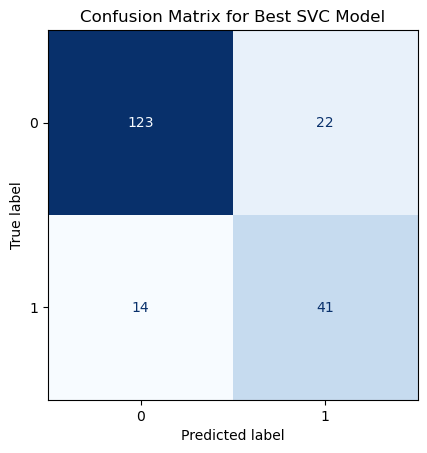

          Classification Report for Best SVC Model          
              precision  recall  f1-score  support
0                  0.90    0.85      0.87   145.00
1                  0.65    0.75      0.69    55.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.77    0.80      0.78   200.00
weighted avg       0.83    0.82      0.82   200.00




In [185]:
# randomized search for hyperparameter tuning for SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
# Define the parameter grid for SVC
param_dist = {
    'C': uniform(0.1, 10),  # Uniform distribution for C
    'gamma': uniform(0.001, 0.1),  # Uniform distribution for gamma
    'kernel': ['linear', 'rbf', 'poly'],  # Different kernel types
    'degree': randint(2, 5)  # Random integer for polynomial degree
}
# Initialize the SVC model
svc = SVC(random_state=42)
# Perform Randomized Search
random_search = RandomizedSearchCV(svc, param_distributions=param_dist, n_iter=50, cv=5, scoring='f1', n_jobs=-1, random_state=42)
# Fit the model
random_search.fit(X_train_smotetom, y_train_smotetom)
# Print the best parameters and score
print("Best Parameters for SVC:", random_search.best_params_)
print("Best F1 Score for SVC:", random_search.best_score_)
# Evaluate the best SVC model on the test set
best_svc_model = random_search.best_estimator_
y_pred_test = best_svc_model.predict(X_test)
y_pred_train = best_svc_model.predict(X_train_smotetom)
test_f1 = f1_score(y_test, y_pred_test)
train_f1 = f1_score(y_train_smotetom, y_pred_train)
print(f"SVC - Test F1: {test_f1:.4f}, Train F1: {train_f1:.4f}")
# Confusion Matrix for the best SVC model
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svc_model.classes_)
disp.plot(cmap='Blues', colorbar=False) 
plt.title("Confusion Matrix for Best SVC Model")
plt.grid(False)
plt.show()
# Classification Report for the best SVC model
report = classification_report(y_test, y_pred_test, output_dict=True)
print("=" * 60)
print(f"{'Classification Report for Best SVC Model':^60}")
print("=" * 60)
df_report = pd.DataFrame(report).transpose()
print(df_report)
print("\n")

#### Gridsearch RandomForest

In [222]:
#gridsearch randomforest    
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
# Define the parameter grid for Random Forest       
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
}
# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)
# Perform Grid Search
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
# Fit the model
grid_search_rf.fit(X_train_smotetom, y_train_smotetom)
# Print the best parameters and score
print("Best Parameters for Random Forest:", grid_search_rf.best_params_)
print("Best F1 Score for Random Forest:", grid_search_rf.best_score_)
# Evaluate the best Random Forest model on the test set
best_rf_model = grid_search_rf.best_estimator_
y_pred_test = best_rf_model.predict(X_test)
y_pred_train = best_rf_model.predict(X_train_smotetom)
test_f1 = f1_score(y_test, y_pred_test)
train_f1 = f1_score(y_train_smotetom, y_pred_train)
print(f"Random Forest - Test F1: {test_f1:.4f}, Train F1: {train_f1:.4f}")
# Confusion Matrix for the best Random Forest model
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix for Best Random Forest Model")
plt.grid(False)
plt.show()
# Classification Report for the best Random Forest model
report = classification_report(y_test, y_pred_test, output_dict=True)
print("=" * 60)
print(f"{'Classification Report for Best Random Forest Model':^60}")
print("=" * 60)
df_report = pd.DataFrame(report).transpose()
print(df_report)

KeyboardInterrupt: 

# K Fold on LDA, Ridge, LogReg, AdaBoos, SVC and RandomForest with Smote Tomek

F1 Scores of Positive Class
Cross-validation for Logistic Regression
Cross-validation for Linear Discriminant Analysis
Cross-validation for Ridge Classifier
Cross-validation for AdaBoost
Cross-validation for SVC
Cross-validation for Random Forest


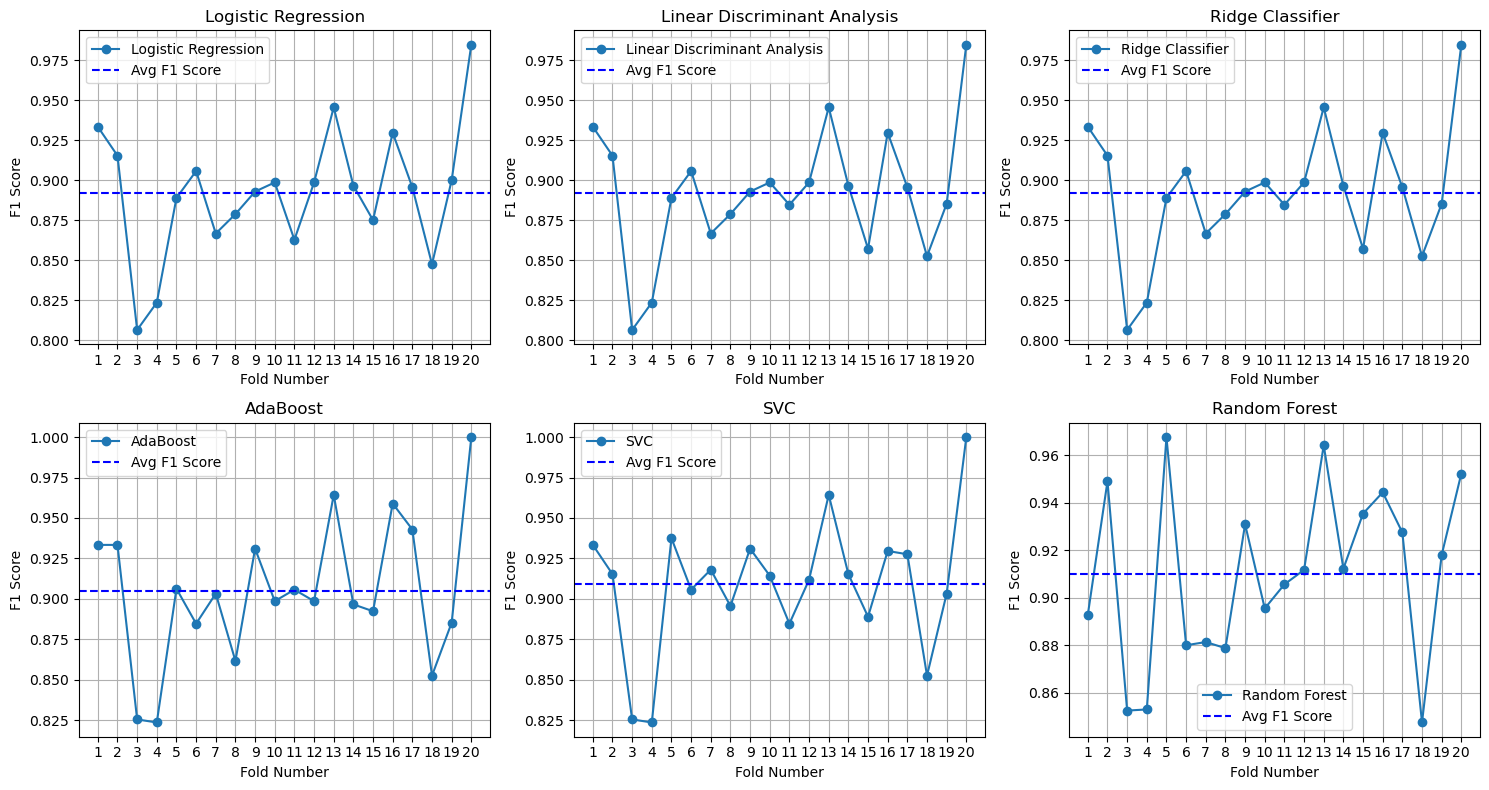

Best Model: Random Forest
Test F1 Score: 0.7350
Train F1 Score: 1.0000
Variance of F1 Scores for each model:
Logistic Regression: 0.0016
Linear Discriminant Analysis: 0.0016
Ridge Classifier: 0.0016
AdaBoost: 0.0019
SVC: 0.0016
Random Forest: 0.0013


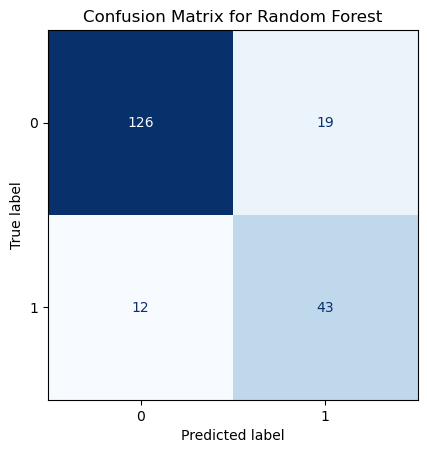

In [223]:
# Do a Kfold for Log.Reg, LDA, Ridge, Adaboost, SVM and Randomforest,  6 splits, and plot all the F1 scores of the positive class in a line graph
#show the line charts as subplots, 3 per row
# use smotetomel set
print ('F1 Scores of Positive Class')
# Define the models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(solver='svd', shrinkage=None),
    'Ridge Classifier': RidgeClassifier(random_state=42, solver='auto', alpha=0.01),
    'AdaBoost': AdaBoostClassifier(random_state=42, algorithm='SAMME', learning_rate=0.1, n_estimators=300),
    'SVC': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}
# Define the number of splits for KFold
n_splits = 20
# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)    
# Initialize a dictionary to store the F1 scores for each model
f1_scores_dict = {}
results_cv = {} # Initialize results_cv dictionary
# Loop through the models
for model_name, model in models.items():
    print(f"Cross-validation for {model_name}")
    # Initialize a list to store the F1 scores for each fold
    f1_scores = []
    # Loop through the folds
    for train_index, val_index in kf.split(X_train_smotetom):
        X_train_fold, X_val_fold = X_train_smotetom.iloc[train_index], X_train_smotetom.iloc[val_index]
        y_train_fold, y_val_fold = y_train_smotetom.iloc[train_index], y_train_smotetom.iloc[val_index]
        # Fit the model
        model.fit(X_train_fold, y_train_fold)
        # Predict on the validation set
        y_val_pred = model.predict(X_val_fold)
        # Calculate F1 score for the positive class
        f1 = f1_score(y_val_fold, y_val_pred)
        f1_scores.append(f1)
    # Store the F1 scores in the dictionary
    f1_scores_dict[model_name] = f1_scores
    results_cv[model_name] = np.mean(f1_scores) # Store mean F1 score for each model
# Plot the F1 scores for each model
plt.figure(figsize=(15, 8))    
# Loop through the models and plot their F1 scores
for i, (model_name, f1_scores) in enumerate(f1_scores_dict.items()):
    plt.subplot(2, 3, i + 1)
    plt.plot(range(1, n_splits + 1), f1_scores, marker='o', label=model_name)
    plt.axhline(y=np.mean(f1_scores), color='blue', linestyle='--', label='Avg F1 Score')
    plt.xlabel('Fold Number')
    plt.ylabel('F1 Score')
    plt.title(model_name)
    plt.xticks(range(1, n_splits + 1))
    plt.legend()
    plt.grid()
plt.tight_layout()
plt.show()
# Final Model Evaluation
# Choose the best model based on the F1 score
# Final Model Evaluation
# Choose the best model based on the F1 score
best_model_name = max(results_cv, key=results_cv.get)
best_model = models[best_model_name]
# Fit the best model on the entire training set
best_model.fit(X_train_smotetom, y_train_smotetom)
# Predict on the test set
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train_smotetom)
# Calculate F1 score for the test and train sets
test_f1 = f1_score(y_test, y_pred_test)
train_f1 = f1_score(y_train_smotetom, y_pred_train)
print(f"Best Model: {best_model_name}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Train F1 Score: {train_f1:.4f}")

# variance of f1 scores of the positive class of each model
print("Variance of F1 Scores for each model:")
for model_name, f1_scores in f1_scores_dict.items():
    variance = np.var(f1_scores)
    print(f"{model_name}: {variance:.4f}")


# Confusion Matrix for the best model   
cm = confusion_matrix(y_test, y_pred_test)
try:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
except AttributeError:
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix for {best_model_name}")
plt.grid(False)
plt.show()

# SHAP Model Interpretability